In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [82]:
DATA_PATH = Path("../data/raw/human_cognitive_performance.csv")
df = pd.read_csv(DATA_PATH)

In [83]:
df.head()

,User_ID,Age,Gender,Sleep_Duration,Stress_Level,Diet_Type,Daily_Screen_Time,Exercise_Frequency,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score,AI_Predicted_Score
0,U1,57,Female,6.5,3,Non-Vegetarian,6.5,Medium,41,583.33,65,36.71,39.77
1,U2,39,Female,7.6,9,Non-Vegetarian,10.8,High,214,368.24,58,54.35,57.68
2,U3,26,Male,8.2,6,Vegetarian,5.7,Low,429,445.21,49,32.57,29.54
3,U4,32,Male,7.8,9,Vegetarian,8.3,Low,464,286.33,94,70.15,74.59
4,U5,50,Male,9.7,2,Non-Vegetarian,11.3,Medium,365,237.65,62,87.54,91.78


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             80000 non-null  object 
 1   Age                 80000 non-null  int64  
 2   Gender              80000 non-null  object 
 3   Sleep_Duration      80000 non-null  float64
 4   Stress_Level        80000 non-null  int64  
 5   Diet_Type           80000 non-null  object 
 6   Daily_Screen_Time   80000 non-null  float64
 7   Exercise_Frequency  80000 non-null  object 
 8   Caffeine_Intake     80000 non-null  int64  
 9   Reaction_Time       80000 non-null  float64
 10  Memory_Test_Score   80000 non-null  int64  
 11  Cognitive_Score     80000 non-null  float64
 12  AI_Predicted_Score  80000 non-null  float64
dtypes: float64(5), int64(4), object(4)
memory usage: 7.9+ MB


In [85]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
User_ID,80000,80000,U79984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,80000.0,NaN,NaN,NaN,38.525525,12.101876,18.0,28.0,39.0,49.0,59.0
Gender,80000,3,Female,38404,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep_Duration,80000.0,NaN,NaN,NaN,7.005332,1.734435,4.0,5.5,7.0,8.5,10.0
Stress_Level,80000.0,NaN,NaN,NaN,5.493762,2.865308,1.0,3.0,5.0,8.0,10.0
Diet_Type,80000,3,Non-Vegetarian,47986,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Daily_Screen_Time,80000.0,NaN,NaN,NaN,6.504646,3.167072,1.0,3.8,6.5,9.2,12.0
Exercise_Frequency,80000,3,Medium,31990,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Caffeine_Intake,80000.0,NaN,NaN,NaN,248.988213,144.54199,0.0,123.0,249.0,375.0,499.0
Reaction_Time,80000.0,NaN,NaN,NaN,399.973579,115.369329,200.0,300.15,400.36,499.25,599.99


In [86]:
df.isna().sum().sort_values(ascending=False)

User_ID               0
Age                   0
Gender                0
Sleep_Duration        0
Stress_Level          0
Diet_Type             0
Daily_Screen_Time     0
Exercise_Frequency    0
Caffeine_Intake       0
Reaction_Time         0
Memory_Test_Score     0
Cognitive_Score       0
AI_Predicted_Score    0
dtype: int64

In [87]:
df.columns.tolist()

['User_ID',
 'Age',
 'Gender',
 'Sleep_Duration',
 'Stress_Level',
 'Diet_Type',
 'Daily_Screen_Time',
 'Exercise_Frequency',
 'Caffeine_Intake',
 'Reaction_Time',
 'Memory_Test_Score',
 'Cognitive_Score',
 'AI_Predicted_Score']

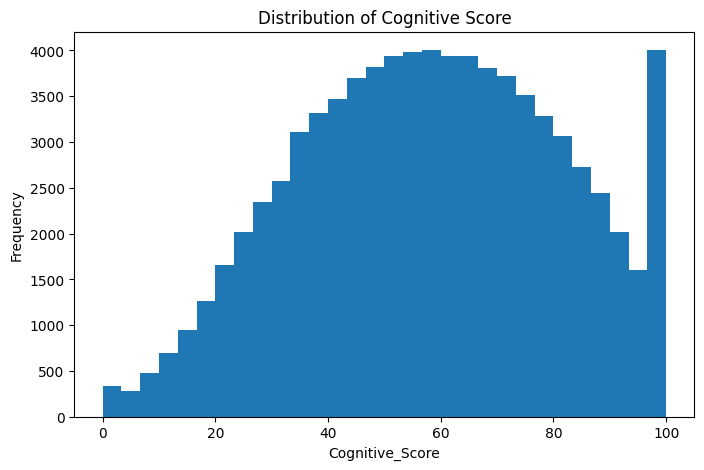

In [88]:
target_col = "Cognitive_Score"

plt.figure(figsize=(8, 5))
plt.hist(df[target_col], bins=30)
plt.xlabel(target_col)
plt.ylabel("Frequency")
plt.title("Distribution of Cognitive Score")
plt.show()

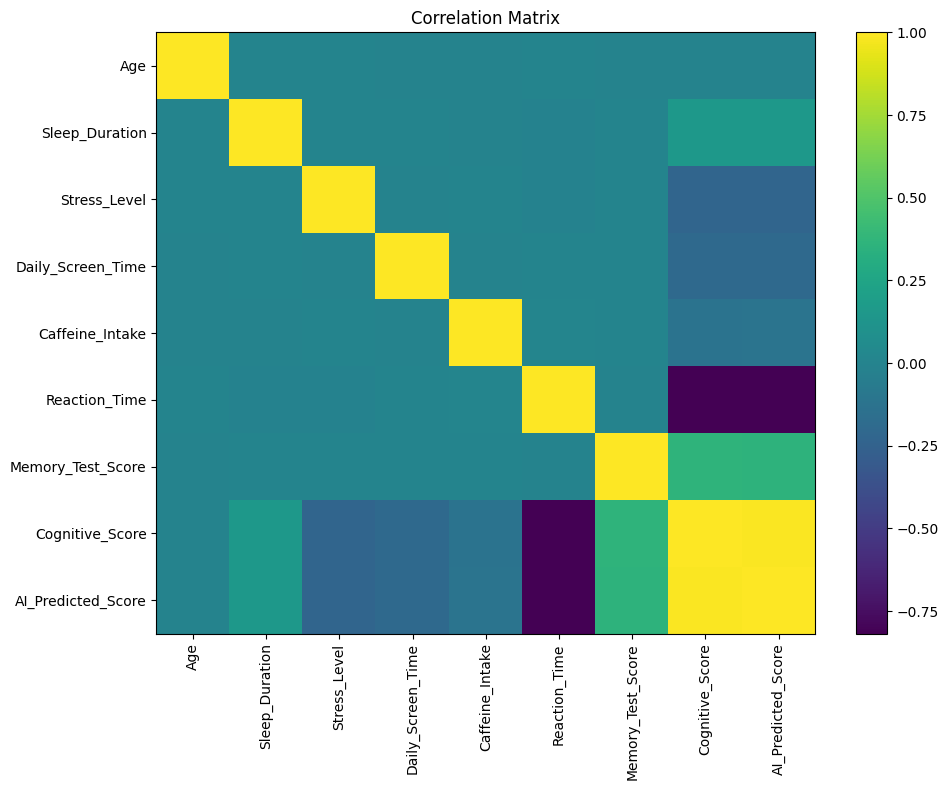

In [89]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Key Insights from Correlation Analysis

- Reaction time shows a strong negative correlation with cognitive performance, suggesting that slower responses are associated with lower scores.
- Memory test score is positively correlated, indicating that memory ability plays a key role in cognitive performance.
- Stress level has a moderate negative impact, aligning with expectations from cognitive psychology.
- Sleep duration and screen time show weaker relationships, suggesting they may have indirect or secondary effects.
- The AI_Predicted_Score is almost perfectly correlated with the target and is excluded to prevent data leakage.

In [90]:
corr_with_target = (
    numeric_df.corr(numeric_only=True)[target_col]
    .sort_values(ascending=False)
)

corr_with_target

Cognitive_Score       1.000000
AI_Predicted_Score    0.992358
Memory_Test_Score     0.363894
Sleep_Duration        0.150595
Age                  -0.005976
Caffeine_Intake      -0.122862
Daily_Screen_Time    -0.198515
Stress_Level         -0.227639
Reaction_Time        -0.818470
Name: Cognitive_Score, dtype: float64

Stress vs Cognitive Score

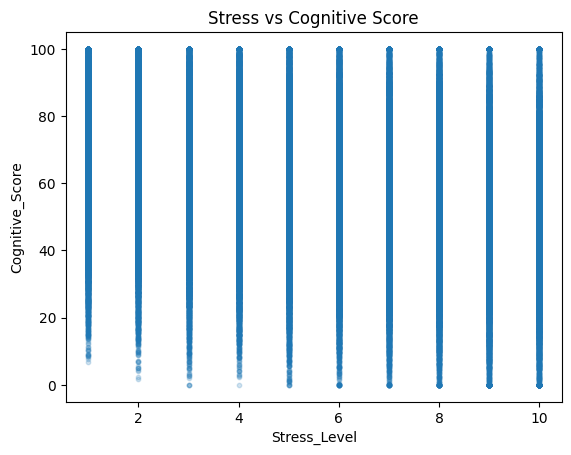

In [91]:
plt.scatter(df["Stress_Level"], df["Cognitive_Score"], alpha=0.2, s=10)
plt.xlabel("Stress_Level")
plt.ylabel("Cognitive_Score")
plt.title("Stress vs Cognitive Score")
plt.show()

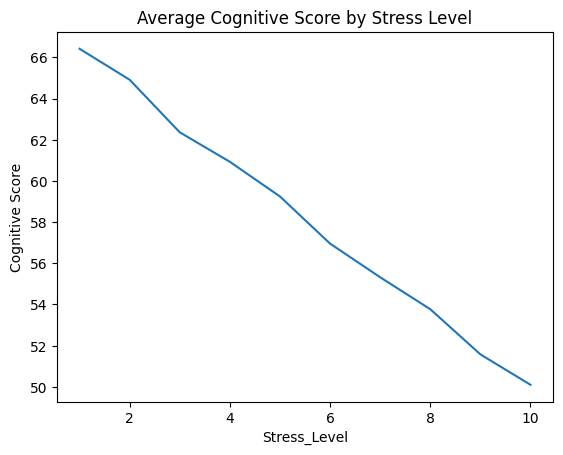

In [92]:
df.groupby("Stress_Level")["Cognitive_Score"].mean().plot(kind="line")
plt.title("Average Cognitive Score by Stress Level")
plt.ylabel("Cognitive Score")
plt.show()

The average cognitive score shows a clear decreasing trend as stress levels increase, indicating a strong negative relationship between stress and cognitive performance.
This suggests that higher stress may significantly impair cognitive abilities.

Sleep vs Cognitive Score

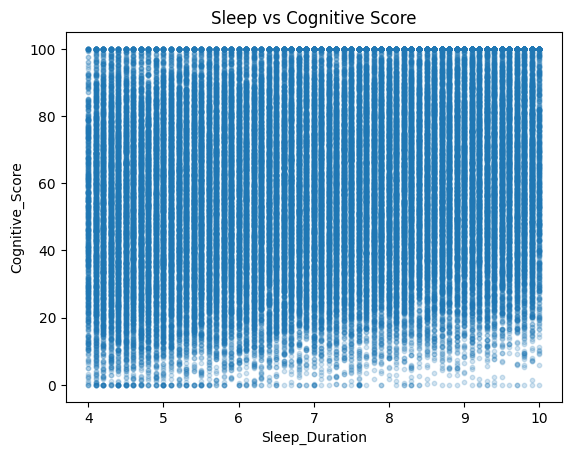

In [93]:
plt.scatter(df["Sleep_Duration"], df["Cognitive_Score"], alpha=0.2, s=10)
plt.xlabel("Sleep_Duration")
plt.ylabel("Cognitive_Score")
plt.title("Sleep vs Cognitive Score")
plt.show()

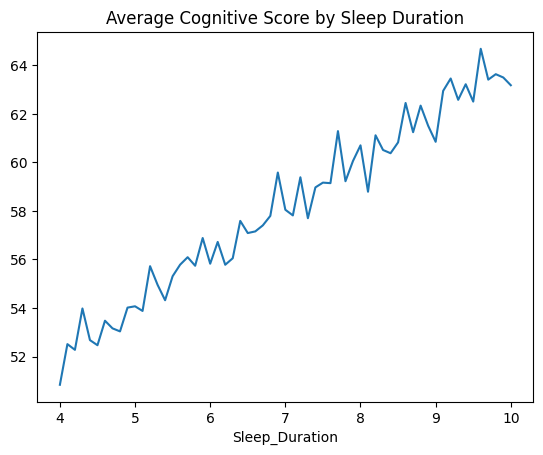

In [94]:
df.groupby("Sleep_Duration")["Cognitive_Score"].mean().plot()
plt.title("Average Cognitive Score by Sleep Duration")
plt.show()

The average cognitive score increases as sleep duration grows, suggesting a positive relationship between sleep and cognitive performance.
Although the trend is not perfectly linear, it indicates that longer sleep is generally associated with better cognitive outcomes.

The raw scatter plots are difficult to interpret due to high data density (overplotting).
To better understand the relationship, we analyze the average cognitive score for each value of the variable.

Reaction Time vs Cognitive Score

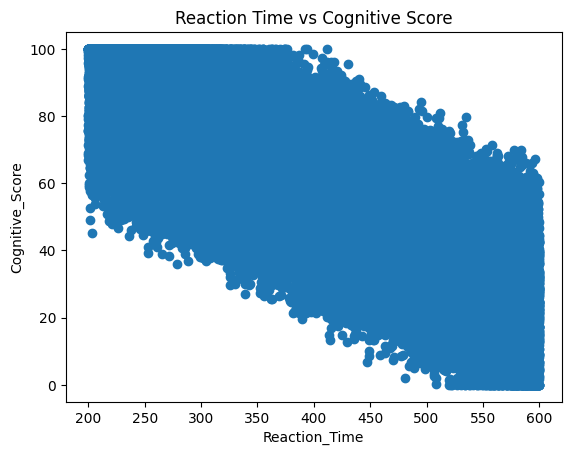

In [95]:
plt.scatter(df["Reaction_Time"], df["Cognitive_Score"])
plt.xlabel("Reaction_Time")
plt.ylabel("Cognitive_Score")
plt.title("Reaction Time vs Cognitive Score")
plt.show()

The scatter plot confirms a strong negative relationship between reaction time and cognitive performance.

Memory Test Score vs Cognitive Score

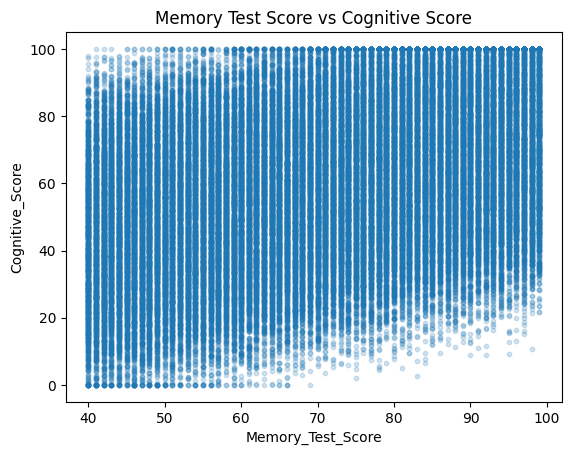

In [96]:
plt.scatter(df["Memory_Test_Score"], df["Cognitive_Score"], alpha=0.2, s=10)
plt.xlabel("Memory_Test_Score")
plt.ylabel("Cognitive_Score")
plt.title("Memory Test Score vs Cognitive Score")
plt.show()

The scatter plot shows a clear positive relationship between memory test score and cognitive performance.
Despite some variability, higher memory scores are generally associated with higher cognitive scores, indicating a strong link between memory ability and overall cognitive function.

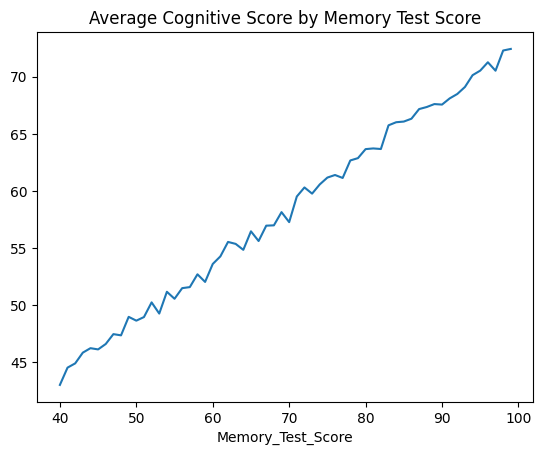

In [97]:
df.groupby("Memory_Test_Score")["Cognitive_Score"].mean().plot()
plt.title("Average Cognitive Score by Memory Test Score")
plt.show()

The average cognitive score increases consistently as memory test score rises, confirming a strong positive relationship between the two variables.
This suggests that memory performance is one of the most influential factors in determining overall cognitive ability.
Although the scatter plot shows some dispersion, the aggregated trend highlights a clear and consistent pattern.

Summary

Based on the correlation analysis, the most relevant features appear to be:
- Reaction Time (strong negative correlation)
- Memory Test Score (strong positive correlation)
- Stress Level (moderate negative correlation)

## Preprocessing

In [98]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder 

In [99]:
x = df.drop(columns=['User_ID','Cognitive_Score','AI_Predicted_Score'])
y = df['Cognitive_Score']
benchmark = df['AI_Predicted_Score']

In [100]:
feature_names = x.columns.tolist()
numeric_features = x.select_dtypes(include=['number']).columns.tolist()
categorical_features = x.select_dtypes(include=['object']).columns.tolist()
print(numeric_features)
print(categorical_features)

['Age', 'Sleep_Duration', 'Stress_Level', 'Daily_Screen_Time', 'Caffeine_Intake', 'Reaction_Time', 'Memory_Test_Score']
['Gender', 'Diet_Type', 'Exercise_Frequency']


In [101]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

In [102]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [103]:
preprocess = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## Train test split

In [104]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Random Forest Regressor

In [105]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [106]:
rf = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ))
])

In [107]:
sample_size = 0.2

# Seleziona un campione casuale dal training set per velocizzare la CV
x_train_sample, _, y_train_sample, _ = train_test_split(
    x_train, y_train, train_size=sample_size, random_state=42
)

print(f"Dimensioni del training set originale: {x_train.shape}")
print(f"Dimensioni del campione del training set: {x_train_sample.shape}")

Dimensioni del training set originale: (64000, 10)
Dimensioni del campione del training set: (12800, 10)


In [108]:
#cross-validation
cv = KFold(n_splits=3, shuffle=True, random_state=42)
cv_r2_sample   = cross_val_score(rf, x_train_sample, y_train_sample, cv=cv, scoring="r2")
cv_mae_sample = -cross_val_score(rf, x_train_sample, y_train_sample, cv=cv, scoring="neg_mean_absolute_error")
cv_rmse_sample = -cross_val_score(rf, x_train_sample, y_train_sample, cv=cv, scoring="neg_root_mean_squared_error")

print("\nRandom Forest – Train (cv) sul campione -")
print("R²   (mean ± std):", np.round(cv_r2_sample.mean(), 3), "±", np.round(cv_r2_sample.std(), 3))
print("MAE (mean ± std):", np.round(cv_mae_sample.mean(), 3), "±", np.round(cv_mae_sample.std(), 3))
print("RMSE (mean ± std):", np.round(cv_rmse_sample.mean(), 3), "±", np.round(cv_rmse_sample.std(), 3))


Random Forest – Train (cv) sul campione -
R²   (mean ± std): 0.975 ± 0.001
MAE (mean ± std): 2.944 ± 0.015
RMSE (mean ± std): 3.702 ± 0.029


In [109]:
# Fit sul train set
rf.fit(x_train, y_train)

#test sul test set
y_pred_rf = rf.predict(x_test)

print("\nRandom Forest – Test -")
print("MAE :", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", mean_squared_error(y_test, y_pred_rf))
print("R²  :", r2_score(y_test, y_pred_rf))


Random Forest – Test -
MAE : 1.9936687591542122
RMSE: 6.3863578391511755
R²  : 0.9878821141074179


The model shows strong predictive performance, with high R² values both in cross-validation and on the test set.

The relatively low MAE indicates that the model is able to predict cognitive scores with good accuracy.

However, the difference between cross-validation and test RMSE suggests that some variability in prediction error remains, possibly due to data distribution differences or model sensitivity.

The high performance may also indicate that the dataset contains strongly predictive features, making the task relatively easy compared to real-world scenarios.

## Feature Importance

In [110]:
import pandas as pd

In [111]:
# feature names after preprocessing
feature_names = rf.named_steps["preprocess"].get_feature_names_out()

# importance
importances = rf.named_steps["model"].feature_importances_

feat_importance = pd.Series(importances, index=feature_names).sort_values(ascending=False)

feat_importance.head(10)

num__Reaction_Time                0.673797
num__Memory_Test_Score            0.131472
cat__Exercise_Frequency_Low       0.057225
num__Stress_Level                 0.053562
num__Daily_Screen_Time            0.040570
num__Sleep_Duration               0.021693
num__Caffeine_Intake              0.015469
num__Age                          0.002059
cat__Exercise_Frequency_Medium    0.001396
cat__Exercise_Frequency_High      0.001392
dtype: float64

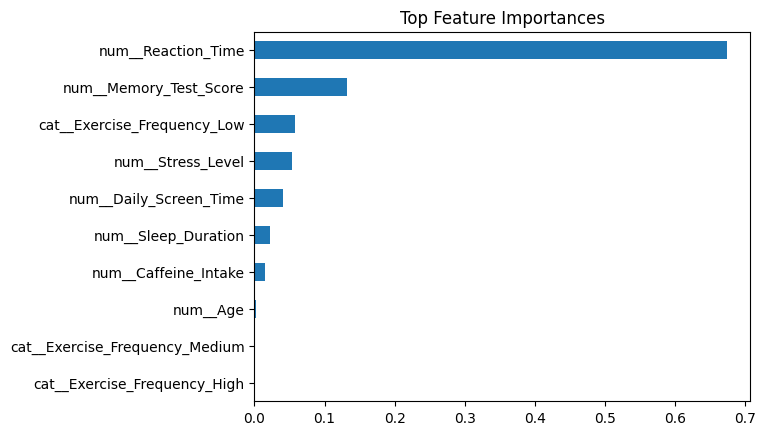

In [112]:
feat_importance.head(10).plot(kind="barh")
plt.title("Top Feature Importances")
plt.gca().invert_yaxis()
plt.show()

The feature importance analysis partially confirms the initial hypothesis.

Reaction time and memory test score are among the most influential variables, aligning with the correlation analysis.

However, exercise frequency also emerges as an important feature, despite showing weaker linear correlation with the target. This highlights how tree-based models can capture non-linear relationships and interactions that are not visible through simple correlation analysis.

Stress level, although moderately correlated with cognitive performance, appears less influential in the model, possibly due to overlap with other features.

## Dummy Regressor

In [113]:
from sklearn.dummy import DummyRegressor

In [114]:
dummy = Pipeline([
    ("preprocess", preprocess),
    ("model", DummyRegressor(strategy="mean"))
])

dummy.fit(x_train, y_train)
y_pred_dummy = dummy.predict(x_test)

In [118]:
print("\nDummy Regressor - Test")
print("MAE :", mean_absolute_error(y_test, y_pred_dummy))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dummy)))
print("R²  :", r2_score(y_test, y_pred_dummy))


Dummy Regressor - Test
MAE : 19.109944821484373
RMSE: 22.956911445296964
R²  : -1.2144128997970682e-06


## Benchmark AI

In [123]:
ai_pred = df.loc[x_test.index, "AI_Predicted_Score"]

In [127]:
print("\nAI Benchmark - Test")
print("MAE :", mean_absolute_error(y_test, ai_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test, ai_pred)))
print("R²  :", r2_score(y_test, ai_pred))


AI Benchmark - Test
MAE : 2.4301412499999997
RMSE: 2.8383559501937032
R²  : 0.9847135258639945


## Model Comparison

In [129]:
results = pd.DataFrame({
    "Model": ["Dummy", "Random Forest", "AI Benchmark"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_dummy),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, ai_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_dummy )),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, ai_pred))
    ],
    "R2": [
        r2_score(y_test, y_pred_dummy),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, ai_pred)
    ]
})

results

,Model,MAE,RMSE,R2
0,Dummy,19.109945,22.956911,-0.000001
1,Random Forest,1.993669,2.527124,0.987882
2,AI Benchmark,2.430141,2.838356,0.984714


The Random Forest model significantly outperforms the Dummy Regressor, confirming that it is effectively learning meaningful patterns from the data.

Compared to the AI benchmark, the model achieves slightly better performance, with lower error metrics and higher R². This suggests that a relatively simple tree-based model can capture the underlying relationships in the dataset very effectively.

These results highlight the strong predictive power of key variables such as reaction time and memory score, which appear to drive most of the model’s performance.

Overall, the task appears relatively easy due to the presence of highly informative features, which may not fully reflect the complexity of real-world cognitive modeling.